# How `glori` actually generates a new sky

`tutorials/tutorial_getting_started.ipynb` shows *how to call* the sampler. This notebook is the conceptual companion: what is actually happening, mechanically, between "give me a new sky" and getting back a 512px image?

The short version: **encoding real images only ever happens once, offline, to build the training set.** Generating a new sky starts from pure noise, runs it through ~25 rounds of denoising, and only decodes to pixels at the very end. No real image is read, encoded, or modified during generation — not even when you condition on a real catalog.

Figures below are reproduced from the paper this repository implements:

> T. Vicánek Martínez and M. Brüggen (2026), *"Generating radio continuum survey maps of arbitrary size with latent diffusion models"*, A&A, arXiv:[2609.06549](https://arxiv.org/abs/2609.06549)

## Two networks, two different jobs

| | VQ-VAE | Denoiser |
|---|---|---|
| Job | Compress an image ↔ a small latent grid | Generate a *new*, plausible latent grid |
| Input | Pixels (256px patch) | Noise (+ optional catalog context) |
| Runs during generation? | **Once**, at the very end (decode only) | **Repeatedly** (25 steps), this is where the actual creative work happens |
| Class | `glori.models.vae.vqvae.VQVAE` | `glori.models.diffusion.denoiser.Denoiser` |

It's tempting to think of sampling as "take an image, encode it, change something in latent space, decode it back" — like an edit. That's not what happens. Read on.

## Training time (once, offline): the only place real images get encoded

Before any of this notebook's sampling happens, at training time:

1. Real LoTSS-DR3 cutouts are run through the VQ-VAE's **encoder** once, producing a training set of latent grids (128×128×3 per 512px patch).
2. The **denoiser** is trained to reverse a noise-corruption process on *those latents* — i.e. given a latent with some amount of Gaussian noise added, predict what the clean latent looked like.

Once training is done, this encoding step is baked into the denoiser's weights. It never happens again — generating a new sky does not touch the encoder at all.

## 0. Setup

Same checkpoints as the getting-started tutorial.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from glori.config.swiit_config import SWIITSamplerConfig
from glori.inference.swiit_sampler import SWIITSampler
from glori.data.trf.scalers import LOFARScaler
from glori.hub import download_pretrained

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

# Downloads (and caches) from the public Hugging Face repo the first time this
# runs: https://huggingface.co/astrokevin/glori-ldm-swiit
DENOISER_CKPT = download_pretrained("denoiser")
VAE_CKPT = download_pretrained("vae")
SCALER_PATH = download_pretrained("scaler")

def plot_map(img, title="", ax=None, cmap="inferno"):
    img = np.asarray(img)
    if img.ndim == 3:
        img = img.squeeze()
    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(5, 5))
    vmin, vmax = np.percentile(img, [1, 99])
    im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, origin="lower")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    if created_fig:
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.show()
    return im

config = SWIITSamplerConfig(
    denoiser="unused", denoiser_ckpt=DENOISER_CKPT,
    vae="unused", vae_ckpt=VAE_CKPT,
    device=DEVICE,
)
sampler = SWIITSampler(config=config)
sampler.scaler = LOFARScaler(**torch.load(SCALER_PATH, weights_only=False))
print("Ready.")

/hs/fs08/data/group-brueggen/tmartinez/envs/cenv_glori/lib/python3.11/site-packages/stringcolor/main.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


 21:40:25 (SWIITSampler)

 - 

INFO 

: Overriding config with provided kwargs...

...

 21:40:40 (SWIITSampler)

 - 

INFO 

: ICM Sampler initialized.

Ready.

## Step 1 — start from pure noise

Generation begins with a tensor of pure Gaussian noise, shaped like a real latent grid (`3×128×128` for a single 512px patch). There is no image here — just `torch.randn`.

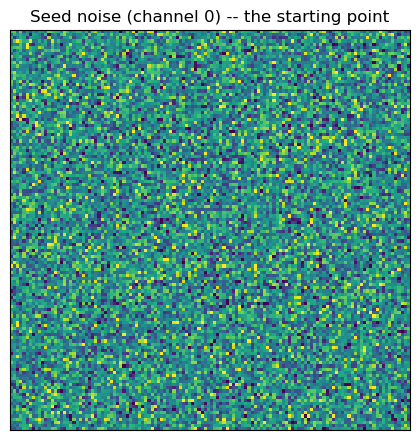

In [2]:
torch.manual_seed(0)
seed_noise = torch.randn(3, 128, 128)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
plot_map(seed_noise[0], title="Seed noise (channel 0) -- the starting point", ax=ax, cmap="viridis")
plt.tight_layout()
plt.show()

## Step 2 — ~25 rounds of denoising turn noise into a latent sky

The denoiser U-Net is called repeatedly (`timesteps=25` by default). At each step `t`, it looks at the current noisy latent and predicts what the clean latent underneath looks like; the sampler then nudges the current latent a small step toward that prediction — removing a bit of noise. After 25 of these steps, pure static has gradually become a coherent, in-distribution latent code: structurally like a real encoded sky, but invented, not reconstructed from anything.

This is genuinely iterative and sequential — each step's output feeds the next step's input. It's also the expensive part: 25 network evaluations (50 with classifier-free guidance, see below) per patch, vs. a single VQ-VAE decode at the very end.

## Step 3 (optional) — catalog context steers the denoising, at every step

If you pass a `ctxt_map` (see `tutorials/tutorial_getting_started.ipynb`, Sections 2–3), it's fed into the denoiser at **every one of the 25 steps** via classifier-free guidance: the network runs twice per step (once with your context, once with a "no context" null input), and the two outputs are blended by `guidance_strength`. This is what steers the noise toward putting sources at specific positions/brightnesses, rather than just "some plausible sky".

## Step 4 — decode, once, at the very end

Only after all 25 denoising steps finish does the final latent go through the VQ-VAE's **decoder** — the one and only decode step — turning the finished latent grid into a pixel-space image. `scaler.inverse_scale()` then converts the model's internal numeric range back into physical, Jy/beam-like units.

Let's actually run this end to end, starting from the exact noise tensor plotted above, so the "before" and "after" are directly comparable:

 21:40:40 (SWIITSampler)

 - 

INFO 

: Preparig context map...

 21:40:40 (SWIITSampler)

...

 21:41:14 (SWIITSampler)

 - 

INFO 

: Decoding latents...

Decoding latents:   0%|          | 0/4 [00:00<?, ?step/s]

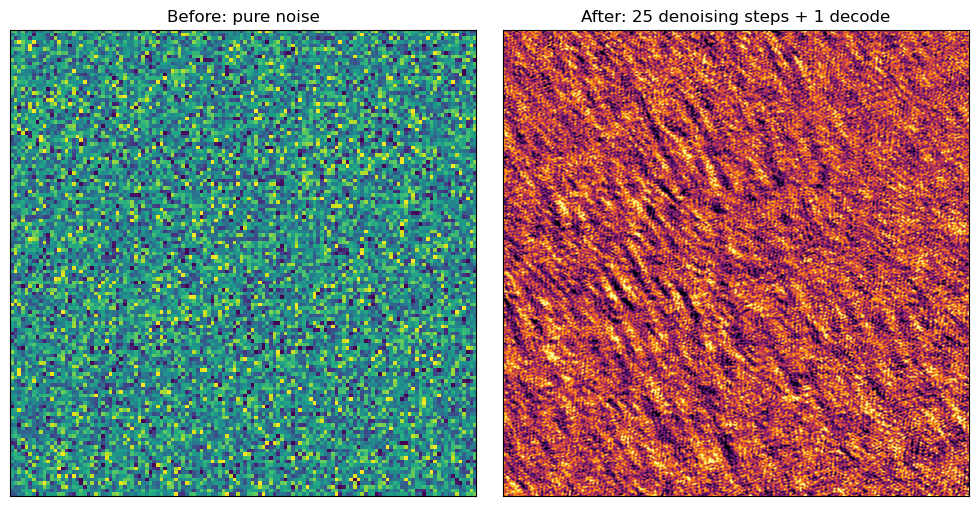

In [3]:
torch.manual_seed(0)  # same seed as the noise plotted above

map_image, latent_map = sampler.sample(timesteps=25)
physical_map = sampler.scaler.inverse_scale(map_image)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_map(seed_noise[0], title="Before: pure noise", ax=axes[0], cmap="viridis")
plot_map(physical_map[0], title="After: 25 denoising steps + 1 decode", ax=axes[1])
plt.tight_layout()
plt.show()

## The full procedure, visually

The paper's Figure 1 shows exactly this loop (a `DM` box = one denoising pass, boxes labelled *Sampled image* = a running decode preview, not an actual per-step decode) — plus SWIIT's extension of it: for a map bigger than one patch, the sliding window repeats this whole noise-to-latent process per grid cell, but constrains the overlap region to match the neighboring patch that was *already generated* (never a real image) via inpainting. That's the `Inpainting context` / black-and-white mask panels below.

![SWIIT sampling schematic, from the paper (Fig. 1)](assets/paper_fig1_swiit_schematic.png)

*Figure reproduced from Vicánek Martínez & Brüggen (2026), Fig. 1.*

## Does this actually look like a real sky?

This is the paper's own comparison (Fig. 12): a real LoTSS test cutout on the left, a map the model generated — conditioned on that same real cutout's catalog, but built entirely from noise via the procedure above — on the right. Sources land at matching positions with matching brightness/size; pixel values are not identical, because nothing here is a reconstruction. (`tutorials/tutorial_getting_started.ipynb` Section 3 reproduces this exact comparison live, on this repo's own checkpoints.)

![Real vs. SWIIT-sampled test map, from the paper (Fig. 12)](assets/paper_fig12_real_vs_generated.png)

*Figure reproduced from Vicánek Martínez & Brüggen (2026), Fig. 12.*

## Recap

| | Happens... | Uses the... |
|---|---|---|
| Encode a real image | Once, offline, during training data prep | VQ-VAE **encoder** |
| Start from noise | Every time you generate | Nothing — just `torch.randn` |
| Denoise (×25, or ×50 with guidance) | Every time you generate | Denoiser U-Net, optionally + catalog context |
| Stitch neighboring patches (SWIIT only) | Every time you generate a multi-patch map | Already-*generated* neighboring latents, via inpainting — never a real image |
| Decode to pixels | Once, at the very end | VQ-VAE **decoder** |

**Where to go next:**
- `tutorials/tutorial_getting_started.ipynb` — the hands-on API walkthrough (unconditional sampling, catalog conditioning, SWIIT maps, real-catalog examples).
- `tutorials/tutorial_legacy_mapmaker.ipynb` — the *other*, unrelated pipeline this repo also contains (T-RECS catalog + per-source rendering, no diffusion sampling loop at map-assembly time).
- The paper (arXiv:2609.06549), Sections 2–3, for the full mathematical treatment (the EDM-style update rule, the exact guidance formula, and the inpainting mask bookkeeping).